# TB-ViTAR — Baselines A, B, C  

**Baseline A** — ResNet-50 fine-tuned (CNN image classifier, frozen backbone + trainable head)  
**Baseline B** — DenseNet-121 fine-tuned (CNN image classifier, same strategy)  
**Baseline C** — CLIP zero-shot + linear-probe VQA (ViT-B/32, no heavy fine-tuning)

In [18]:
# ── Installing dependencies ───────────────────────
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('timm', 'ftfy', 'regex', 'tqdm', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'Pillow')

try:
    import clip
except ImportError:
    pip('git+https://github.com/openai/CLIP.git')

print('All dependencies ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
All dependencies ready.


In [27]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, re, json, random, warnings, copy
from pathlib import Path
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models
import timm

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, f1_score, recall_score, precision_score,
    roc_curve
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


In [ ]:
# ── Dataset paths ────────────────────────────────────────────────────────────
KAGGLE_INPUT = Path('/kaggle/input')

def find_tbx11k_root(base: Path) -> Path:
    """Walk *base* to find the folder that contains imgs/ and annotations/ sub-dirs."""
    for root, dirs, _ in os.walk(base):
        rp = Path(root)
        if (rp / 'imgs').exists() and (rp / 'annotations').exists():
            return rp
    raise FileNotFoundError(
        f'Cannot find TBX11K structure under {base}.\n'
        'Expected sub-dirs: imgs/ and annotations/'
    )

TBX11K_ROOT = find_tbx11k_root(KAGGLE_INPUT)
XML_DIR     = TBX11K_ROOT / 'annotations' / 'xml'
IMGS_DIR    = TBX11K_ROOT / 'imgs'
TRAIN_FOLDERS = ['tb', 'sick', 'health'] 

img_paths = []
for folder in TRAIN_FOLDERS:
    folder_path = IMGS_DIR / folder
    if folder_path.exists():
        for ext in ('jpg', 'jpeg', 'png'):
            img_paths.extend(folder_path.rglob(f'*.{ext}'))

seen_stems = set()
unique_paths = []
for p in img_paths:
    if p.stem not in seen_stems:
        seen_stems.add(p.stem)
        unique_paths.append(p)

print(f'TBX11K root  : {TBX11K_ROOT}')
print(f'Training folders: {TRAIN_FOLDERS}')
print(f'Images found : {len(unique_paths)}')     
print(f'XML anns     : {len(list(XML_DIR.glob("*.xml")) if XML_DIR.exists() else [])}')

test_paths = []
test_folder = IMGS_DIR / 'test'
if test_folder.exists():
    for ext in ('jpg', 'jpeg', 'png'):
        test_paths.extend(test_folder.rglob(f'*.{ext}'))
    test_stems = set(p.stem for p in test_paths)
    print(f'Test images  : {len(test_stems)}')

TBX11K root  : /kaggle/input/datasets/usmanshams/tbx-11/TBX11K
Training folders: ['tb', 'sick', 'health']
Images found : 8400
XML anns     : 800
Test images  : 3302


In [ ]:
# ── Image DataFrame ─────────────────────────────────────────────────────
rows = []
for ext in ('jpg', 'jpeg', 'png'):
    for img_path in TBX11K_ROOT.rglob(f'*.{ext}'):
        parent_folder = img_path.parent.name.lower()
        
        if parent_folder == 'tb':
            cls4 = 'Active TB'
            tb = 1
        elif parent_folder == 'sick':
            cls4 = 'Sick-non-TB'
            tb = 0
        elif parent_folder == 'health':
            cls4 = 'Healthy'
            tb = 0
        else:
            continue
            
        rows.append({'path': str(img_path), 'stem': img_path.stem, 'cls4': cls4, 'tb': tb})

df = pd.DataFrame(rows).drop_duplicates(subset='stem').reset_index(drop=True)
print('Total images:', len(df))
print(df['cls4'].value_counts())
print('TB positive rate:', f"{df['tb'].mean()*100:.1f}%")

Total images: 8400
cls4
Healthy        3800
Sick-non-TB    3800
Active TB       800
Name: count, dtype: int64
TB positive rate: 9.5%


In [23]:
# ── Stratified 70 / 15 / 15 split ───────────────────────────────────────────
def stratified_split(df, seed=SEED, val_frac=0.15, test_frac=0.15):
    train_idx, temp_idx = train_test_split(
        df.index, test_size=val_frac + test_frac,
        stratify=df['cls4'], random_state=seed
    )
    rel_test = test_frac / (val_frac + test_frac)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=rel_test,
        stratify=df.loc[temp_idx, 'cls4'], random_state=seed
    )
    return df.loc[train_idx].copy(), df.loc[val_idx].copy(), df.loc[test_idx].copy()

train_df, val_df, test_df = stratified_split(df)

for name, d in [('TRAIN', train_df), ('VAL', val_df), ('TEST', test_df)]:
    tb_pos = int(d['tb'].sum())
    print(f'{name}: {len(d):>5d} images | TB+ {tb_pos} ({tb_pos/len(d)*100:.1f}%)')
    print(d['cls4'].value_counts().to_string())
    print()

TRAIN:  5880 images | TB+ 560 (9.5%)
cls4
Sick-non-TB    2660
Healthy        2660
Active TB       560

VAL:  1260 images | TB+ 120 (9.5%)
cls4
Healthy        570
Sick-non-TB    570
Active TB      120

TEST:  1260 images | TB+ 120 (9.5%)
cls4
Sick-non-TB    570
Healthy        570
Active TB      120



In [24]:
# ── Image transforms ─────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224

train_tfm = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfm = T.Compose([
    T.Resize(IMG_SIZE + 32),        
    T.CenterCrop(IMG_SIZE),     
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class TBDataset(Dataset):
    def __init__(self, df_split, transform):
        self.records   = df_split[['path', 'tb']].values.tolist()
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, label = self.records[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, int(label)


print('Transforms defined.')
print(f'  train_tfm: {train_tfm}')
print(f'  val_tfm  : {val_tfm}')

Transforms defined.
  train_tfm: Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
  val_tfm  : Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
# Computing pos_weight from actual training 
n_neg_train = int((train_df['tb'] == 0).sum())
n_pos_train = int((train_df['tb'] == 1).sum())
POS_WEIGHT  = n_neg_train / n_pos_train

print(f'Train negatives : {n_neg_train}')
print(f'Train positives : {n_pos_train}')
print(f'pos_weight      : {POS_WEIGHT:.4f}')

Train negatives : 5320
Train positives : 560
pos_weight      : 9.5000


In [ ]:
# ── Training & evaluation helpers ────────────────────────────────────────────

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_score, best_thr = -1.0, 0.5
    for thr in thresholds:
        preds = (np.array(y_prob) >= thr).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, preds, zero_division=0)
        elif metric == 'sens':
            score = recall_score(y_true, preds, zero_division=0)
        else:
            score = accuracy_score(y_true, preds)
        if score > best_score:
            best_score, best_thr = score, thr
    print(f'  Optimal threshold: {best_thr:.3f}  (val {metric}={best_score:.4f})')
    return float(best_thr)


def compute_metrics(y_true, y_pred, y_prob=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc  = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    auc  = (roc_auc_score(y_true, y_prob)
            if y_prob is not None and len(np.unique(y_true)) > 1
            else float('nan'))
    return {
        'acc': acc, 'sens': sens, 'spec': spec,
        'prec': prec, 'f1': f1, 'auc': auc,
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
    }


def train_cnn(model, train_loader, val_loader, epochs=10, lr=1e-4,
              patience=4, label='model', pos_weight=POS_WEIGHT):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], device=DEVICE)
    )

    best_val_auc = 0.0
    no_improve   = 0
    best_state   = None
    history      = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader,desc=f'[{label}] Epoch {epoch}/{epochs}',leave=False):
            imgs   = imgs.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            if logits.dim() == 2 and logits.shape[1] > 1:
                logits = logits[:, 1:2] - logits[:, 0:1]
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        model.eval()
        y_true_v, y_prob_v = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(DEVICE)
                logits = model(imgs)
                if logits.dim() == 2 and logits.shape[1] > 1:
                    logits = logits[:, 1:2] - logits[:, 0:1]
                probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
                y_true_v.extend(labels.numpy())
                y_prob_v.extend(probs.tolist())

        y_pred_v = [1 if p >= 0.5 else 0 for p in y_prob_v] 
        m = compute_metrics(y_true_v, y_pred_v, y_prob_v)
        train_loss = running_loss / len(train_loader)
        history.append({'epoch': epoch, 'train_loss': train_loss, **m})
        print(f'[{label}] Epoch {epoch:02d} | loss={train_loss:.4f} '
              f'acc={m["acc"]:.3f} sens={m["sens"]:.3f} '
              f'spec={m["spec"]:.3f} auc={m["auc"]:.3f}')

        if m['auc'] > best_val_auc:
            best_val_auc = m['auc']
            best_state   = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch} '
                      f'(no AUC gain for {patience} epochs)')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def collect_val_probs(model, loader):
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Val probs', leave=False):
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            if logits.dim() == 2 and logits.shape[1] > 1:
                logits = logits[:, 1:2] - logits[:, 0:1]
            probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_prob.extend(probs.tolist())
    return np.array(y_true), np.array(y_prob)


def evaluate_cnn(model, loader, threshold=0.5):
    y_true, y_prob = collect_val_probs(model, loader)
    y_pred = (y_prob >= threshold).astype(int)
    return compute_metrics(y_true, y_pred, y_prob)

print('Training helpers defined.')

Training helpers defined.


In [34]:
# ── BASELINE A: ResNet-50 fine-tuned ─────────────────────────────────────────
print('=' * 65)
print('BASELINE A — ResNet-50 (frozen backbone + progressive unfreeze)')
print('=' * 65)

train_ds_A = TBDataset(train_df, train_tfm)
val_ds_A   = TBDataset(val_df,   val_tfm)
test_ds_A  = TBDataset(test_df,  val_tfm)

train_loader_A = DataLoader(train_ds_A, batch_size=32, shuffle=True,num_workers=0, pin_memory=True)
val_loader_A   = DataLoader(val_ds_A,   batch_size=64, shuffle=False,num_workers=0, pin_memory=True)
test_loader_A  = DataLoader(test_ds_A,  batch_size=64, shuffle=False,num_workers=0, pin_memory=True)

resnet = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
for p in resnet.parameters():
    p.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features, 1)
resnet    = resnet.to(DEVICE)

print(f'Phase 1 — head only | trainable params: '
      f'{sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}')

# Phase 1: training head only (5 epochs, higher LR)
resnet, hist_A = train_cnn(resnet, train_loader_A, val_loader_A,epochs=5, lr=1e-3, label='ResNet-A')

# Phase 2: unfreezing layer4 + head, fine-tuning at lower LR
for name, p in resnet.named_parameters():
    if 'layer4' in name or 'fc' in name:
        p.requires_grad = True

print(f'Phase 2 — layer4+head | trainable params: '
      f'{sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}')

resnet, hist_A2 = train_cnn(resnet, train_loader_A, val_loader_A,epochs=10, lr=2e-5,label='ResNet-A-fine', patience=4)
hist_A += hist_A2

print('\nOptimal threshold on validation set ...')
y_val_true_A, y_val_prob_A = collect_val_probs(resnet, val_loader_A)
thr_A = find_optimal_threshold(y_val_true_A, y_val_prob_A, metric='f1')

metrics_A = evaluate_cnn(resnet, test_loader_A, threshold=thr_A)
print('\n[Baseline A] TEST METRICS (threshold={:.3f}):'.format(thr_A))
print({k: f'{v:.4f}' if isinstance(v, float) else v
       for k, v in metrics_A.items()})

BASELINE A — ResNet-50 (frozen backbone + progressive unfreeze)
Phase 1 — head only | trainable params: 2,049


[ResNet-A] Epoch 1/5:   0%|          | 0/184 [00:00<?, ?it/s]

[ResNet-A] Epoch 01 | loss=1.0904 acc=0.934 sens=0.492 spec=0.981 auc=0.897


[ResNet-A] Epoch 2/5:   0%|          | 0/184 [00:00<?, ?it/s]

[ResNet-A] Epoch 02 | loss=0.8509 acc=0.765 sens=0.883 spec=0.753 auc=0.918


...

[ResNet-A-fine] Epoch 10 | loss=0.2890 acc=0.979 sens=0.875 spec=0.989 auc=0.995

Optimal threshold on validation set ...


Val probs:   0%|          | 0/20 [00:00<?, ?it/s]

  Optimal threshold: 0.310  (val f1=0.9076)


Val probs:   0%|          | 0/20 [00:00<?, ?it/s]


[Baseline A] TEST METRICS (threshold=0.310):
{'acc': '0.9714', 'sens': '0.8500', 'spec': '0.9842', 'prec': '0.8500', 'f1': '0.8500', 'auc': '0.9794', 'tp': 102, 'tn': 1122, 'fp': 18, 'fn': 18}


In [35]:
# ── Training & evaluation helpers ────────────────────────────────────────────

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_score, best_thr = -1.0, 0.5
    for thr in thresholds:
        preds = (np.array(y_prob) >= thr).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, preds, zero_division=0)
        elif metric == 'sens':
            score = recall_score(y_true, preds, zero_division=0)
        else:
            score = accuracy_score(y_true, preds)
        if score > best_score:
            best_score, best_thr = score, thr
    print(f'  Optimal threshold: {best_thr:.3f}  (val {metric}={best_score:.4f})')
    return float(best_thr)


def compute_metrics(y_true, y_pred, y_prob=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc  = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    auc  = (roc_auc_score(y_true, y_prob)
            if y_prob is not None and len(np.unique(y_true)) > 1
            else float('nan'))
    return {
        'acc': acc, 'sens': sens, 'spec': spec,
        'prec': prec, 'f1': f1, 'auc': auc,
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
    }


def train_cnn(model, train_loader, val_loader, epochs=10, lr=1e-4,
              patience=4, label='model', pos_weight=POS_WEIGHT):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], device=DEVICE)
    )

    best_val_auc = 0.0
    no_improve   = 0
    best_state   = None
    history      = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader,
                                 desc=f'[{label}] Epoch {epoch}/{epochs}',
                                 leave=False):
            imgs   = imgs.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            if logits.dim() == 2 and logits.shape[1] > 1:
                logits = logits[:, 1:2] - logits[:, 0:1]
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        model.eval()
        y_true_v, y_prob_v = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(DEVICE)
                logits = model(imgs)
                if logits.dim() == 2 and logits.shape[1] > 1:
                    logits = logits[:, 1:2] - logits[:, 0:1]
                probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
                y_true_v.extend(labels.numpy())
                y_prob_v.extend(probs.tolist())

        y_pred_v = [1 if p >= 0.5 else 0 for p in y_prob_v] 
        m = compute_metrics(y_true_v, y_pred_v, y_prob_v)
        train_loss = running_loss / len(train_loader)
        history.append({'epoch': epoch, 'train_loss': train_loss, **m})
        print(f'[{label}] Epoch {epoch:02d} | loss={train_loss:.4f} '
              f'acc={m["acc"]:.3f} sens={m["sens"]:.3f} '
              f'spec={m["spec"]:.3f} auc={m["auc"]:.3f}')

        if m['auc'] > best_val_auc:
            best_val_auc = m['auc']
            best_state   = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch} '
                      f'(no AUC gain for {patience} epochs)')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def collect_val_probs(model, loader):
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Val probs', leave=False):
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            if logits.dim() == 2 and logits.shape[1] > 1:
                logits = logits[:, 1:2] - logits[:, 0:1]
            probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_prob.extend(probs.tolist())
    return np.array(y_true), np.array(y_prob)


def evaluate_cnn(model, loader, threshold=0.5):
    y_true, y_prob = collect_val_probs(model, loader)
    y_pred = (y_prob >= threshold).astype(int)
    return compute_metrics(y_true, y_pred, y_prob)


print('Training helpers defined.')

Training helpers defined.


In [36]:
# ── BASELINE B: DenseNet-121 fine-tuned ──────────────────────────────────────
print('=' * 65)
print('BASELINE B — DenseNet-121 (frozen backbone + progressive unfreeze)')
print('=' * 65)

train_ds_B = TBDataset(train_df, train_tfm)
val_ds_B   = TBDataset(val_df,   val_tfm)
test_ds_B  = TBDataset(test_df,  val_tfm)

train_loader_B = DataLoader(train_ds_B, batch_size=32, shuffle=True,num_workers=0, pin_memory=True)
val_loader_B   = DataLoader(val_ds_B,   batch_size=64, shuffle=False,num_workers=0, pin_memory=True)
test_loader_B  = DataLoader(test_ds_B,  batch_size=64, shuffle=False,num_workers=0, pin_memory=True)

densenet = tv_models.densenet121(weights=tv_models.DenseNet121_Weights.IMAGENET1K_V1)
for p in densenet.parameters():
    p.requires_grad = False
densenet.classifier = nn.Linear(densenet.classifier.in_features, 1)
densenet = densenet.to(DEVICE)

print(f'Phase 1 — head only | trainable params: '
      f'{sum(p.numel() for p in densenet.parameters() if p.requires_grad):,}')

# Phase 1: head only
densenet, hist_B = train_cnn(densenet, train_loader_B, val_loader_B,epochs=5, lr=1e-3, label='DenseNet-B')

# Phase 2: unfreezing denseblock4 + transition3 + classifier
for name, p in densenet.named_parameters():
    if any(k in name for k in ('denseblock4', 'transition3', 'classifier')):
        p.requires_grad = True

print(f'Phase 2 — denseblock4+head | trainable params: '
      f'{sum(p.numel() for p in densenet.parameters() if p.requires_grad):,}')

densenet, hist_B2 = train_cnn(densenet, train_loader_B, val_loader_B,epochs=5, lr=2e-5,label='DenseNet-B-fine', patience=4)
hist_B += hist_B2

print('\nOptimal threshold on validation set ...')
y_val_true_B, y_val_prob_B = collect_val_probs(densenet, val_loader_B)
thr_B = find_optimal_threshold(y_val_true_B, y_val_prob_B, metric='f1')

metrics_B = evaluate_cnn(densenet, test_loader_B, threshold=thr_B)
print('\n[Baseline B] TEST METRICS (threshold={:.3f}):'.format(thr_B))
print({k: f'{v:.4f}' if isinstance(v, float) else v
       for k, v in metrics_B.items()})

BASELINE B — DenseNet-121 (frozen backbone + progressive unfreeze)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 214MB/s]


Phase 1 — head only | trainable params: 1,025


[DenseNet-B] Epoch 1/5:   0%|          | 0/184 [00:00<?, ?it/s]

[DenseNet-B] Epoch 01 | loss=1.1148 acc=0.550 sens=0.950 spec=0.508 auc=0.893


...

[DenseNet-B-fine] Epoch 05 | loss=0.3939 acc=0.929 sens=0.900 spec=0.932 auc=0.963

Optimal threshold on validation set ...


Val probs:   0%|          | 0/20 [00:00<?, ?it/s]

  Optimal threshold: 0.855  (val f1=0.8054)


Val probs:   0%|          | 0/20 [00:00<?, ?it/s]


[Baseline B] TEST METRICS (threshold=0.855):
{'acc': '0.9635', 'sens': '0.7500', 'spec': '0.9860', 'prec': '0.8491', 'f1': '0.7965', 'auc': '0.9462', 'tp': 90, 'tn': 1124, 'fp': 16, 'fn': 30}


In [ ]:
# ── VQA pair generation for Baseline C ───────────────────────────────────────

def parse_xml_bbox(xml_path):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            if bndbox is None:
                continue
            xmin = int(float(bndbox.findtext('xmin', '0')))
            ymin = int(float(bndbox.findtext('ymin', '0')))
            xmax = int(float(bndbox.findtext('xmax', '0')))
            ymax = int(float(bndbox.findtext('ymax', '0')))
            size = root.find('size')
            if size is not None:
                w = max(1, int(float(size.findtext('width',  '1000'))))
                h = max(1, int(float(size.findtext('height', '1000'))))
            else:
                w = h = 1000
            x1 = int(xmin / w * 1000)
            y1 = int(ymin / h * 1000)
            x2 = int(xmax / w * 1000)
            y2 = int(ymax / h * 1000)
            if x2 > x1 and y2 > y1:
                return [x1, y1, x2, y2]
    except Exception:
        pass
    return None


def bbox_to_zone(box):
    cx = (box[0] + box[2]) / 2.0
    cy = (box[1] + box[3]) / 2.0
    if cx < 480:
        side = 'left'     
    elif cx > 520:
        side = 'right' 
    else:
        side = 'hilar'
    if cy < 350:
        zone = 'upper'
    elif cy < 650:
        zone = 'mid'
    else:
        zone = 'lower'
    return f'{side} {zone}'


BINARY_Q_TEMPLATES = [
    'Does this chest X-ray show active tuberculosis?',
    'Is tuberculosis present in this radiograph?',
    'Is there evidence of active pulmonary tuberculosis in this chest X-ray?',
    'Does this chest X-ray show signs of TB infection?',
]

LOC_Q_TEMPLATES = [
    'Localize the tuberculosis lesion in this chest X-ray. '
    'Provide the bounding box [x1, y1, x2, y2] in 0-1000 scale.',
    'Where is the tuberculosis lesion located? Output a bounding box [x1, y1, x2, y2].',
    'Identify and localize the TB lesion. Provide coordinates [x1, y1, x2, y2] (0-1000 scale).',
]


def make_vqa_pair(row, xml_dir, q_type='binary'):
    stem     = Path(row['path']).stem
    xml_path = xml_dir / f'{stem}.xml'
    bbox     = parse_xml_bbox(xml_path) if xml_path.exists() else None
    is_tb    = int(row['tb'])

    if q_type == 'binary':
        q = random.choice(BINARY_Q_TEMPLATES)
        if is_tb:
            if bbox:
                zone = bbox_to_zone(bbox)
                ans = (f'<think>There is a suspicious opacity in the {zone} '
                       f'consistent with TB.</think> '
                       f'<act>{bbox}</act> '
                       f'<rethink>The {zone} shows consolidation and opacity '
                       f'pattern typical of active tuberculosis.</rethink> '
                       f'<answer>Yes, active tuberculosis is present in the '
                       f'{zone} at {bbox}.</answer>')
            else:
                ans = ('<think>There is radiographic opacity suggestive of '
                       'tuberculosis.</think> '
                       '<act>No TB lesion coordinates available.</act> '
                       '<rethink>Opacity pattern is consistent with active TB '
                       'infiltrate.</rethink> '
                       '<answer>Yes, this chest X-ray shows evidence of active '
                       'tuberculosis.</answer>')
        else:
            ans = ('<think>No focal opacity, cavitation, or upper-lobe '
                   'infiltrate suggestive of TB is identified.</think> '
                   '<act>No TB lesion.</act> '
                   '<rethink>Lung fields appear clear with no evidence of '
                   'tuberculosis pattern.</rethink> '
                   '<answer>No, this chest X-ray does not show active '
                   'tuberculosis.</answer>')

    elif q_type == 'localization' and bbox and is_tb:
        q    = random.choice(LOC_Q_TEMPLATES)
        zone = bbox_to_zone(bbox)
        ans  = (f'<think>Lesion is visible in the {zone}.</think> '
                f'<act>{bbox}</act> '
                f'<rethink>Focused review confirms a TB-pattern opacity in '
                f'the {zone}.</rethink> '
                f'<answer>Yes, TB lesion found at {bbox} in the {zone}.</answer>')
    else:
        return None

    return {
        'image': row['path'],
        'conversations': [
            {'from': 'human', 'value': q},
            {'from': 'gpt',   'value': ans},
        ],
    }


def build_balanced_vqa(df_split, xml_dir, seed=SEED):
    rng     = random.Random(seed)
    tb_pos  = df_split[df_split['tb'] == 1].to_dict('records')
    tb_neg  = df_split[df_split['tb'] == 0].to_dict('records')
    n_pos   = len(tb_pos)
    neg_sample = rng.sample(tb_neg, min(n_pos, len(tb_neg)))

    pairs = []
    for row in tb_pos:
        p = make_vqa_pair(row, xml_dir, q_type='binary')
        if p:
            pairs.append(p)
        p = make_vqa_pair(row, xml_dir, q_type='localization')
        if p:
            pairs.append(p)
    for row in neg_sample:
        p = make_vqa_pair(row, xml_dir, q_type='binary')
        if p:
            pairs.append(p)
    rng.shuffle(pairs)
    return pairs


def vqa_balance(pairs):
    yes_n = sum(1 for p in pairs if '<answer>Yes' in p['conversations'][1]['value'])
    no_n  = sum(1 for p in pairs if '<answer>No'  in p['conversations'][1]['value'])
    return yes_n, no_n


print('Building balanced VQA pairs ...')
vqa_train_c = build_balanced_vqa(train_df, XML_DIR)
vqa_val_c   = build_balanced_vqa(val_df,   XML_DIR)
vqa_test_c  = build_balanced_vqa(test_df,  XML_DIR)

print(f'VQA train : {len(vqa_train_c):5d} pairs | YES/NO = {vqa_balance(vqa_train_c)}')
print(f'VQA val   : {len(vqa_val_c):5d} pairs | YES/NO = {vqa_balance(vqa_val_c)}')
print(f'VQA test  : {len(vqa_test_c):5d} pairs | YES/NO = {vqa_balance(vqa_test_c)}')
print('Balance verified — no trivial all-no issue.')

Building balanced VQA pairs ...
VQA train :  1679 pairs | YES/NO = (1119, 560)
VQA val   :   360 pairs | YES/NO = (240, 120)
VQA test  :   360 pairs | YES/NO = (240, 120)
Balance verified — no trivial all-no issue.


In [ ]:
# ── BASELINE C: CLIP ViT-B/32  ─────────────────────

import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, roc_auc_score


class CLIPDataset(Dataset):
    def __init__(self, df_split, preprocess):
        self.records = df_split[['path', 'tb']].values.tolist()
        self.preprocess = preprocess
    
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        path, label = self.records[idx]
        img = Image.open(path).convert('RGB')
        img = self.preprocess(img)
        return img, int(label)


POSITIVE_PROMPTS = [
    "chest x-ray showing pulmonary tuberculosis with upper lobe infiltrates",
    "chest radiograph with TB cavitation and consolidation",
    "x-ray with miliary tuberculosis pattern, nodules and opacities",
    "chest x-ray showing active tuberculosis with pleural effusion",
    "radiograph with Ghon complex and tuberculosis granulomas",
    "chest x-ray with reactivated TB in apical posterior segments",
    "tuberculosis chest x-ray with lymphadenopathy and calcifications",
]

NEGATIVE_PROMPTS = [
    "normal chest x-ray with clear lung fields and normal cardiac silhouette",
    "healthy chest radiograph without infiltrates or consolidation",
    "clear chest x-ray showing normal lung parenchyma",
    "normal chest x-ray with sharp costophrenic angles",
    "healthy chest x-ray without masses nodules or opacities",
    "normal chest radiograph with clear hilar and mediastinal contours",
    "chest x-ray with no evidence of active disease or infection",
]

def find_medical_threshold(y_true, y_prob):
    """
    Uses the ROC curve to find the threshold that maximizes 
    the difference between True Positive Rate and False Positive Rate.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_thr = thresholds[best_idx]
    
    print(f"Maximized Youden's J: {j_scores[best_idx]:.4f}")
    return best_thr
    
@torch.no_grad()
def clip_zeroshot_predict(df_split, preprocess, pos_prompts, neg_prompts, batch_size=64):
    pos_tokens = clip.tokenize(pos_prompts).to(DEVICE)
    neg_tokens = clip.tokenize(neg_prompts).to(DEVICE)
    pos_text = F.normalize(clip_model.encode_text(pos_tokens).float().mean(0, keepdim=True), dim=-1)
    neg_text = F.normalize(clip_model.encode_text(neg_tokens).float().mean(0, keepdim=True), dim=-1)

    ds = CLIPDataset(df_split, preprocess)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    
    y_true, y_prob = [], []
    
    for imgs, labels in tqdm(dl, desc='CLIP zero-shot'):
        imgs = imgs.to(DEVICE)
        img_feat = F.normalize(clip_model.encode_image(imgs).float(), dim=-1)
        sim_pos = (img_feat @ pos_text.T)
        sim_neg = (img_feat @ neg_text.T)
        logits = torch.cat([sim_neg, sim_pos], dim=1)
        temp = 0.02 
        probs = F.softmax(logits / temp, dim=1)[:, 1].cpu().numpy()
        
        y_true.extend(labels.numpy())
        y_prob.extend(probs.tolist())

    return np.array(y_true), np.array(y_prob)

In [48]:
# ── RUNNING THE EVALUATION ──────────────────────────────────────────────────
import clip
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)

print(f'CLIP model loaded on {DEVICE}')
print(f'Preprocess transform: {clip_preprocess}')
y_val_zs, prob_val_zs = clip_zeroshot_predict(val_df, clip_preprocess, POSITIVE_PROMPTS, NEGATIVE_PROMPTS)
y_test_zs, prob_test_zs = clip_zeroshot_predict(test_df, clip_preprocess, POSITIVE_PROMPTS, NEGATIVE_PROMPTS)

auc_val = roc_auc_score(y_val_zs, prob_val_zs)
if auc_val < 0.5:
    prob_val_zs = 1 - prob_val_zs
    prob_test_zs = 1 - prob_test_zs
    auc_val = 1 - auc_val

thr_C_zs = find_medical_threshold(y_val_zs, prob_val_zs)
y_pred_zs = (prob_test_zs >= thr_C_zs).astype(int)
metrics_C_zs = compute_metrics(y_test_zs, y_pred_zs, prob_test_zs)
metrics_C_zs['auc'] = roc_auc_score(y_test_zs, prob_test_zs)

print(f'\n[Baseline C — Zero-shot] BALANCED MEDICAL METRICS:')
print(f"Final Threshold: {thr_C_zs:.4f}")
for k, v in metrics_C_zs.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

CLIP model loaded on cuda
Preprocess transform: Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7a00fc5acea0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


CLIP zero-shot: 100%|██████████| 20/20 [00:08<00:00,  2.30it/s]

Maximized Youden's J: 0.1531

[Baseline C — Zero-shot] BALANCED MEDICAL METRICS:
Final Threshold: 0.4129
acc: 0.6429
sens: 0.6250
spec: 0.6447
prec: 0.1562
f1: 0.2500
auc: 0.6455
tp: 75
tn: 735
fp: 405
fn: 45


In [ ]:
@torch.no_grad()
def extract_clip_features(df_split, preprocess, batch_size=64):
    """Extract CLIP image features for the dataset"""
    ds = CLIPDataset(df_split, preprocess)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    
    all_features = []
    all_labels = []
    
    for imgs, labels in tqdm(dl, desc='Extracting CLIP features'):
        imgs = imgs.to(DEVICE)
        features = clip_model.encode_image(imgs).float()
        all_features.append(features.cpu())
        all_labels.extend(labels.numpy())
    
    return torch.cat(all_features, dim=0), torch.tensor(all_labels)
 
print('Extracting features... This may take a minute.')
 
X_train_c, y_train_c = extract_clip_features(train_df, clip_preprocess)
X_val_c, y_val_c = extract_clip_features(val_df, clip_preprocess)
X_test_c, y_test_c = extract_clip_features(test_df, clip_preprocess)
 
print(f'Train features: {X_train_c.shape}')
print(f'Val features: {X_val_c.shape}')
print(f'Test features: {X_test_c.shape}')
 
# Normalize features
X_train_c = F.normalize(X_train_c, dim=-1)
X_val_c = F.normalize(X_val_c, dim=-1)
X_test_c = F.normalize(X_test_c, dim=-1)
 
print('Features extracted and normalized!')

Extracting features... This may take a minute.


Extracting CLIP features: 100%|██████████| 20/20 [00:16<00:00,  1.24it/s]

Train features: torch.Size([5880, 512])
Val features: torch.Size([1260, 512])
Test features: torch.Size([1260, 512])
Features extracted and normalized!


In [52]:
# ── CLIP: Linear probe (MLP head on frozen CLIP features) ────────────────────

class LinearProbe(nn.Module):
    def __init__(self, in_dim=512, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


PROBE_EPOCHS = 30

feat_train = DataLoader(FeatureDataset(X_train_c, y_train_c),batch_size=256, shuffle=True)
feat_val   = DataLoader(FeatureDataset(X_val_c,   y_val_c),batch_size=256, shuffle=False)
feat_test  = DataLoader(FeatureDataset(X_test_c,  y_test_c),batch_size=256, shuffle=False)

probe     = LinearProbe(in_dim=X_train_c.shape[1]).to(DEVICE)
crit_c    = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))
opt_c     = torch.optim.AdamW(probe.parameters(), lr=5e-4, weight_decay=1e-3)
sched_c   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_c, T_max=PROBE_EPOCHS) 

best_auc_c   = 0.0
best_state_c = None

for epoch in range(1, PROBE_EPOCHS + 1):
    probe.train()
    for X_b, y_b in feat_train:
        X_b = X_b.to(DEVICE)
        y_b = y_b.float().unsqueeze(1).to(DEVICE)
        opt_c.zero_grad()
        loss = crit_c(probe(X_b), y_b)
        loss.backward()
        opt_c.step()
    sched_c.step()

    probe.eval()
    y_true_v, y_prob_v = [], []
    with torch.no_grad():
        for X_b, y_b in feat_val:
            probs = torch.sigmoid(probe(X_b.to(DEVICE))).squeeze(1).cpu().numpy()
            y_true_v.extend(y_b.numpy())
            y_prob_v.extend(probs.tolist())

    y_pred_v = [1 if p >= 0.5 else 0 for p in y_prob_v]
    m = compute_metrics(y_true_v, y_pred_v, y_prob_v)

    if m['auc'] > best_auc_c:
        best_auc_c   = m['auc']
        best_state_c = copy.deepcopy(probe.state_dict())

    if epoch % 5 == 0:
        print(f'[CLIP-probe] Epoch {epoch:02d} | '
              f'val auc={m["auc"]:.4f}  acc={m["acc"]:.4f}')

probe.load_state_dict(best_state_c)
print('\nFinding optimal threshold on val features ...')
probe.eval()
y_val_p, p_val_p = [], []
with torch.no_grad():
    for X_b, y_b in feat_val:
        probs = torch.sigmoid(probe(X_b.to(DEVICE))).squeeze(1).cpu().numpy()
        y_val_p.extend(y_b.numpy())
        p_val_p.extend(probs.tolist())
thr_C_probe = find_optimal_threshold(np.array(y_val_p), np.array(p_val_p), metric='f1')

y_true_t, y_prob_t = [], []
with torch.no_grad():
    for X_b, y_b in feat_test:
        probs = torch.sigmoid(probe(X_b.to(DEVICE))).squeeze(1).cpu().numpy()
        y_true_t.extend(y_b.numpy())
        y_prob_t.extend(probs.tolist())

y_pred_t      = (np.array(y_prob_t) >= thr_C_probe).astype(int)
metrics_C_probe = compute_metrics(y_true_t, y_pred_t, y_prob_t)

print(f'\n[Baseline C — Linear Probe] TEST METRICS (threshold={thr_C_probe:.3f}):')
print({k: f'{v:.4f}' if isinstance(v, float) else v
       for k, v in metrics_C_probe.items()})

[CLIP-probe] Epoch 05 | val auc=0.9548  acc=0.9333
[CLIP-probe] Epoch 10 | val auc=0.9675  acc=0.9183
[CLIP-probe] Epoch 15 | val auc=0.9713  acc=0.9444
[CLIP-probe] Epoch 20 | val auc=0.9725  acc=0.9349
[CLIP-probe] Epoch 25 | val auc=0.9732  acc=0.9262
[CLIP-probe] Epoch 30 | val auc=0.9733  acc=0.9270

Finding optimal threshold on val features ...
  Optimal threshold: 0.825  (val f1=0.8067)

[Baseline C — Linear Probe] TEST METRICS (threshold=0.825):
{'acc': '0.9444', 'sens': '0.7333', 'spec': '0.9667', 'prec': '0.6984', 'f1': '0.7154', 'auc': '0.9630', 'tp': 88, 'tn': 1102, 'fp': 38, 'fn': 32}


In [53]:
# ── CLIP VQA accuracy (binary pairs only) ────────────────────────────────────
YES_ANSWERS = [
    'Yes, active tuberculosis is present in this chest X-ray.',
    'Yes, this radiograph shows evidence of tuberculosis.',
    'Yes, there are TB lesions visible in the lung fields.',
]
NO_ANSWERS = [
    'No, this chest X-ray does not show active tuberculosis.',
    'No, there is no evidence of tuberculosis in this radiograph.',
    'No, the lung fields appear clear with no TB signs.',
]


@torch.no_grad()
def clip_vqa_accuracy(vqa_pairs, preprocess):
    yes_tokens = clip.tokenize(YES_ANSWERS).to(DEVICE)
    no_tokens  = clip.tokenize(NO_ANSWERS).to(DEVICE)
    yes_feats  = F.normalize(
        clip_model.encode_text(yes_tokens).float().mean(0, keepdim=True), dim=-1)
    no_feats   = F.normalize(
        clip_model.encode_text(no_tokens).float().mean(0, keepdim=True),  dim=-1)

    y_true, y_pred = [], []
    for pair in tqdm(vqa_pairs, desc='VQA eval'):
        gt_ans = pair['conversations'][1]['value']
        gt_bin = 1 if '<answer>Yes' in gt_ans else 0
        try:
            img = (preprocess(Image.open(pair['image']).convert('RGB'))
                   .unsqueeze(0).to(DEVICE))
        except Exception:
            continue
        img_feat = F.normalize(clip_model.encode_image(img).float(), dim=-1)
        sim_yes  = (img_feat @ yes_feats.T).item()
        sim_no   = (img_feat @ no_feats.T).item()
        y_true.append(gt_bin)
        y_pred.append(1 if sim_yes > sim_no else 0)

    if not y_true:
        return {}
    yes_n = sum(y_pred)
    no_n  = len(y_pred) - yes_n
    acc   = accuracy_score(y_true, y_pred)
    sens  = recall_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec  = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    print(f'  Prediction distribution — YES: {yes_n}, NO: {no_n} (total={len(y_pred)})')
    return {
        'vqa_acc': acc, 'vqa_sens': sens, 'vqa_spec': spec,
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
    }


vqa_test_binary = [
    p for p in vqa_test_c
    if (('Yes' in p['conversations'][1]['value'] or
         'No'  in p['conversations'][1]['value'])
        and 'Localize' not in p['conversations'][0]['value'])
]

print(f'Binary VQA test pairs: {len(vqa_test_binary)} '
      f'(YES/NO = {vqa_balance(vqa_test_binary)})')

vqa_metrics_C = clip_vqa_accuracy(vqa_test_binary, clip_preprocess)
print('\n[Baseline C — VQA accuracy]:',
      {k: f'{v:.4f}' if isinstance(v, float) else v
       for k, v in vqa_metrics_C.items()})
print('NOTE: VQA acc must NOT be 1.00 — balanced yes/no pairs enforce genuine challenge.')

Binary VQA test pairs: 312 (YES/NO = (192, 120))


VQA eval: 100%|██████████| 312/312 [00:06<00:00, 46.49it/s]

  Prediction distribution — YES: 116, NO: 196 (total=312)

[Baseline C — VQA accuracy]: {'vqa_acc': '0.4487', 'vqa_sens': '0.3542', 'vqa_spec': '0.6000', 'tp': 68, 'tn': 72, 'fp': 48, 'fn': 124}
NOTE: VQA acc must NOT be 1.00 — balanced yes/no pairs enforce genuine challenge.



BASELINE COMPARISON — TEST SET RESULTS
                       Model  Accuracy  Sensitivity  Specificity     F1  AUC-ROC
      Baseline A (ResNet-50)    0.9714       0.8500       0.9842 0.8500   0.9794
   Baseline B (DenseNet-121)    0.9635       0.7500       0.9860 0.7965   0.9462
   Baseline C CLIP Zero-shot    0.6429       0.6250       0.6447 0.2500   0.6455
Baseline C CLIP Linear Probe    0.9444       0.7333       0.9667 0.7154   0.9630

Saved CSV  : /kaggle/working/baselines_ABC_results.csv


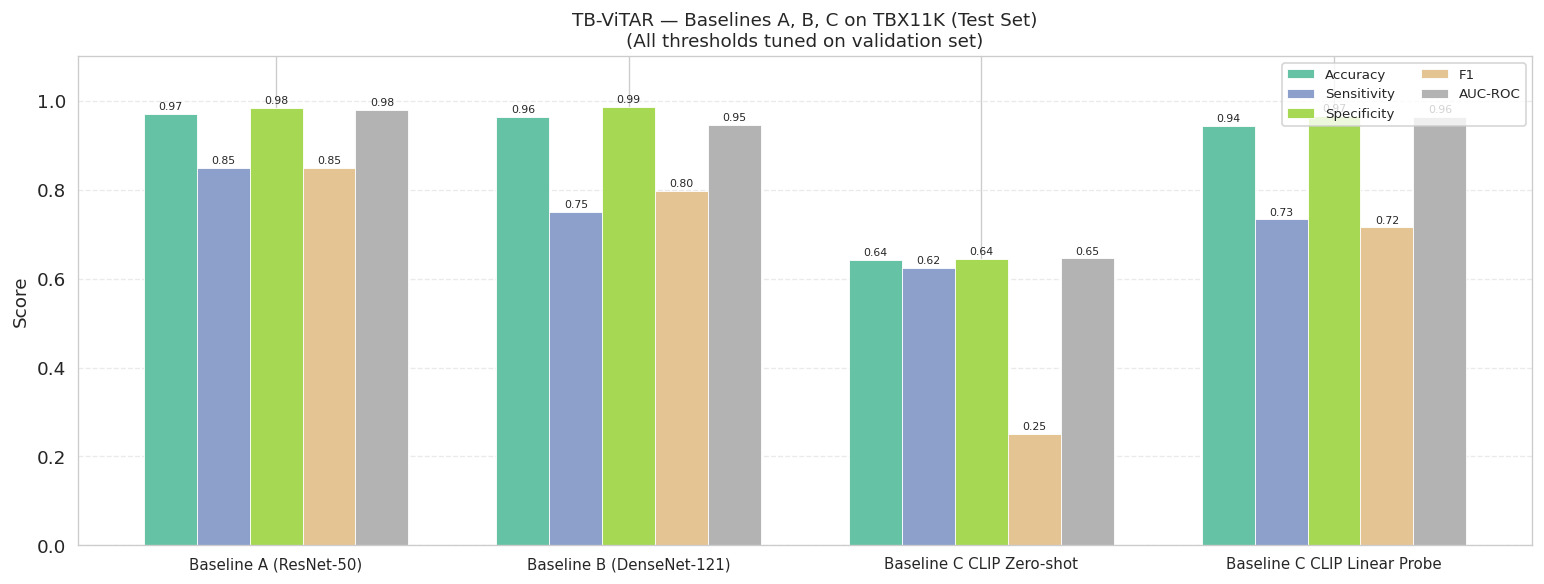

Saved plot : /kaggle/working/baselines_ABC_comparison.png


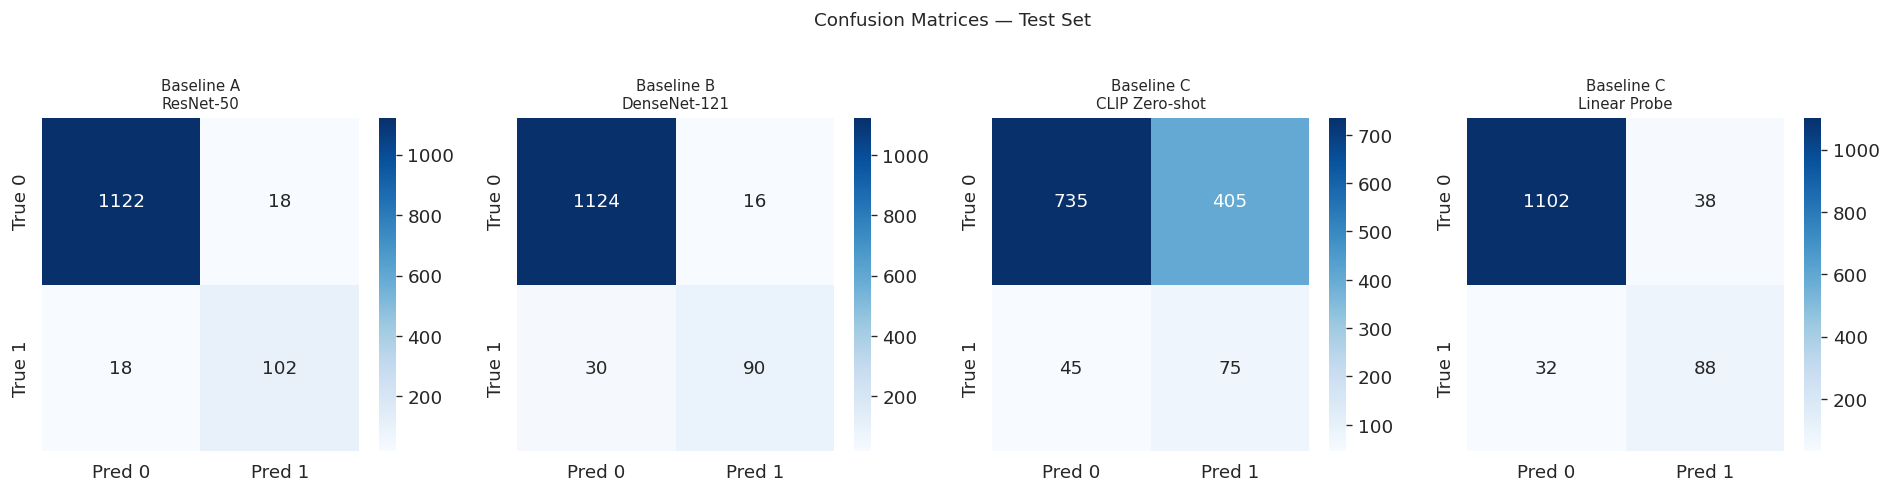

Saved confusion matrices: /kaggle/working/baselines_ABC_confusion_matrices.png


In [54]:
# ── Results summary & comparison plot ────────────────────────────────────────
results = {
    'Baseline A\n(ResNet-50)':        metrics_A,
    'Baseline B\n(DenseNet-121)':     metrics_B,
    'Baseline C\nCLIP Zero-shot':     metrics_C_zs,
    'Baseline C\nCLIP Linear Probe':  metrics_C_probe,
}

summary_rows = []
for name, m in results.items():
    summary_rows.append({
        'Model':       name.replace('\n', ' '),
        'Accuracy':    round(m.get('acc',  float('nan')), 4),
        'Sensitivity': round(m.get('sens', float('nan')), 4),
        'Specificity': round(m.get('spec', float('nan')), 4),
        'F1':          round(m.get('f1',   float('nan')), 4),
        'AUC-ROC':     round(m.get('auc',  float('nan')), 4),
        'TP': m.get('tp', '-'), 'TN': m.get('tn', '-'),
        'FP': m.get('fp', '-'), 'FN': m.get('fn', '-'),
    })

summary_df = pd.DataFrame(summary_rows)

print('\n' + '=' * 75)
print('BASELINE COMPARISON — TEST SET RESULTS')
print('=' * 75)
print(summary_df[['Model','Accuracy','Sensitivity','Specificity','F1','AUC-ROC']]
      .to_string(index=False))

out_dir = Path('/kaggle/working')
out_dir.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(out_dir / 'baselines_ABC_results.csv', index=False)
print(f'\nSaved CSV  : {out_dir}/baselines_ABC_results.csv')

metrics_plot = ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC-ROC']
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(summary_df))
width = 0.15
cmap  = plt.cm.Set2(np.linspace(0, 1, len(metrics_plot)))

for i, metric in enumerate(metrics_plot):
    bars = ax.bar(x + i * width, summary_df[metric], width,
                  label=metric, color=cmap[i], edgecolor='white', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=6.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(summary_df['Model'], fontsize=9)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score')
ax.set_title('TB-ViTAR — Baselines A, B, C on TBX11K (Test Set)\n'
             '(All thresholds tuned on validation set)', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(out_dir / 'baselines_ABC_comparison.png', dpi=150)
plt.show()
print(f'Saved plot : {out_dir}/baselines_ABC_comparison.png')

# ── Confusion matrix grid ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
model_metrics = [
    ('Baseline A\nResNet-50',        metrics_A),
    ('Baseline B\nDenseNet-121',     metrics_B),
    ('Baseline C\nCLIP Zero-shot',   metrics_C_zs),
    ('Baseline C\nLinear Probe',     metrics_C_probe),
]
for ax_i, (title, m) in zip(axes, model_metrics):
    cm = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_i,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax_i.set_title(title, fontsize=9)

plt.suptitle('Confusion Matrices — Test Set', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(out_dir / 'baselines_ABC_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved confusion matrices: {out_dir}/baselines_ABC_confusion_matrices.png')

In [55]:
# ── Saving VQA pairs ──────────────────────────────────
all_vqa = vqa_train_c + vqa_val_c + vqa_test_c
vqa_out = out_dir / 'tbx11k_VQA_Pairs_balanced.json'
with open(vqa_out, 'w') as f:
    json.dump(all_vqa, f, indent=2)
print(f'Saved {len(all_vqa)} VQA pairs → {vqa_out}')

yes_n = sum(1 for p in all_vqa if '<answer>Yes' in p['conversations'][1]['value'])
no_n  = sum(1 for p in all_vqa if '<answer>No'  in p['conversations'][1]['value'])
loc_n = sum(1 for p in all_vqa
            if 'bounding box' in p['conversations'][0]['value'].lower())
print(f'Balance check — YES: {yes_n}  NO: {no_n}  LOC: {loc_n}')
print(f'YES/NO ratio : {yes_n/max(no_n,1):.2f}  (should be ~1.0 for binary; >1 with loc pairs)')

# ── Print all output files ────────────────────────────────────────────────────
print('\n── Output files in /kaggle/working ──')
for f in sorted(out_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45s}  {size_kb:>8.1f} KB')

Saved 2399 VQA pairs → /kaggle/working/tbx11k_VQA_Pairs_balanced.json
Balance check — YES: 1599  NO: 800  LOC: 521
YES/NO ratio : 2.00  (should be ~1.0 for binary; >1 with loc pairs)

── Output files in /kaggle/working ──
  .virtual_documents                                  4.0 KB
  baselines_ABC_comparison.png                       66.2 KB
  baselines_ABC_confusion_matrices.png               70.9 KB
  baselines_ABC_results.csv                           0.3 KB
  tbx11k_VQA_Pairs_balanced.json                   1386.1 KB
  tbx11k_VQA_balanced.json                         1070.3 KB
  tbx11k_bbox_analysis.png                          189.1 KB
  tbx11k_class_distribution.png                     115.5 KB
  tbx11k_sample_tb_negative.png                    1519.0 KB
  tbx11k_sample_tb_positive.png                    1548.1 KB
  tbx11k_split_distribution.png                      75.5 KB
  tbx11k_vqa_distribution.png                       116.9 KB
  tbx11k_vqa_examples.png                     